<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/mcd_robust_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.covariance import MinCovDet

# 1. Load feature matrix (Feature A, Feature B)
data = np.array([
    [1.000, 0.2313],  # RADIANT LIGHT
    [0.679, 0.5662],  # CABLE ROCK
    [0.556, 0.7646],  # CAWARRA
    [0.571, 0.7581],  # ASTONISHER
    [0.571, 0.8107],  # JESA LUPA
    [0.429, 0.5662],  # THE SCHOLAR
    [0.357, 0.7972],  # MILLY'S CLEVER TOO
    [0.179, 1.0387],  # JAVELIN STRIKE
    [0.143, 0.9198],  # COME ON EMMA
    [0.071, 1.3549],  # ANOTHER CHANT
    [0.000, 1.4708]   # AUTHORATIVE
])

# 2. Fit FastMCD / DetMCD
mcd = MinCovDet(support_fraction=0.64, random_state=42).fit(data)

# 3. Compute Robust Mahalanobis Distances
robust_distances = np.sqrt(mcd.dist_)

# 4. Critical threshold based on Chi-Squared distribution (p=2, alpha=0.025)
from scipy.stats import chi2
threshold = np.sqrt(chi2.ppf(0.975, df=2))

# Identify outliers
is_outlier = robust_distances > threshold

<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1601/3818607861.py:40: SyntaxWarning: invalid escape sequence '\c'
  plt.axhline(y=cutoff, color="red", linestyle="--", linewidth=1.5, label=f"Robust Cutoff ($\chi^2_{{2, 0.975}}$ = {cutoff:.2f})")


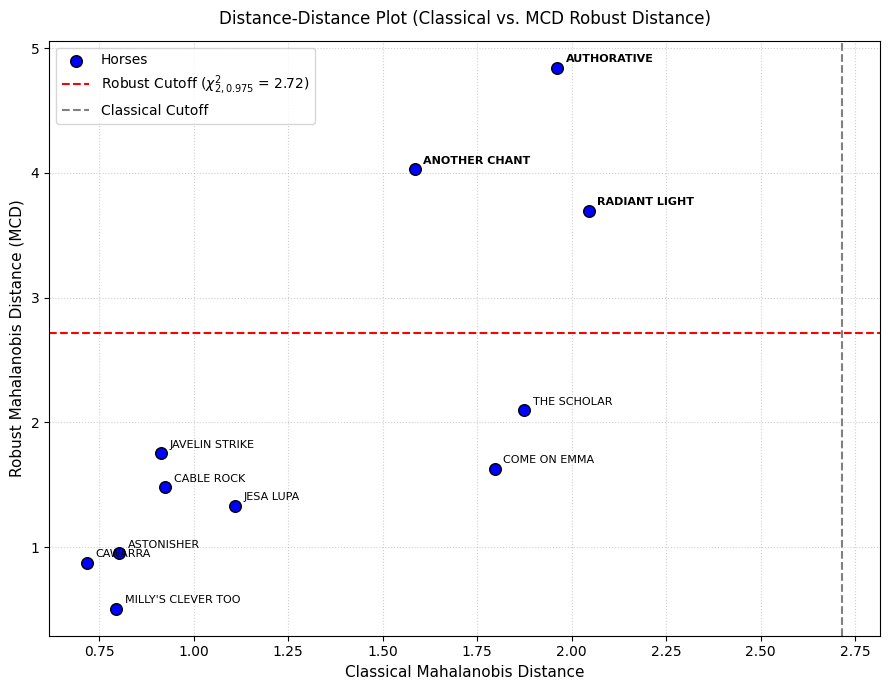

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.covariance import MinCovDet, EmpiricalCovariance

# 1. Dataset Construction
data_dict = {
    "Horse": [
        "RADIANT LIGHT", "CABLE ROCK", "CAWARRA", "ASTONISHER",
        "JESA LUPA", "THE SCHOLAR", "MILLY'S CLEVER TOO",
        "JAVELIN STRIKE", "COME ON EMMA", "ANOTHER CHANT", "AUTHORATIVE"
    ],
    "Feature_A": [1.000, 0.679, 0.556, 0.571, 0.571, 0.429, 0.357, 0.179, 0.143, 0.071, 0.000],
    "Feature_B": [0.2313, 0.5662, 0.7646, 0.7581, 0.8107, 0.5662, 0.7972, 1.0387, 0.9198, 1.3549, 1.4708]
}

df = pd.DataFrame(data_dict)
X = df[["Feature_A", "Feature_B"]].values

# 2. Compute Classical Mahalanobis Distances
emp_cov = EmpiricalCovariance().fit(X)
classical_dist = np.sqrt(emp_cov.mahalanobis(X))

# 3. Compute Robust Mahalanobis Distances (MCD)
# support_fraction ~ 0.64 selects h = 7 out of 11 samples
mcd = MinCovDet(support_fraction=0.64, random_state=42).fit(X)
robust_dist = np.sqrt(mcd.dist_)

# 4. Critical Threshold (Chi-Squared cutoff at alpha = 0.025, df = 2)
cutoff = np.sqrt(chi2.ppf(0.975, df=2))

# 5. Build Distance-Distance Plot
plt.figure(figsize=(9, 7))

# Plot observations
plt.scatter(classical_dist, robust_dist, color="blue", edgecolors="k", s=70, zorder=3, label="Horses")

# Add cutoff lines
plt.axhline(y=cutoff, color="red", linestyle="--", linewidth=1.5, label=f"Robust Cutoff ($\chi^2_{{2, 0.975}}$ = {cutoff:.2f})")
plt.axvline(x=cutoff, color="gray", linestyle="--", linewidth=1.5, label="Classical Cutoff")

# Label each observation on the plot
for i, txt in enumerate(df["Horse"]):
    plt.annotate(
        txt,
        (classical_dist[i], robust_dist[i]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold" if robust_dist[i] > cutoff else "normal"
    )

# Formatting
plt.title("Distance-Distance Plot (Classical vs. MCD Robust Distance)", fontsize=12, pad=12)
plt.xlabel("Classical Mahalanobis Distance", fontsize=11)
plt.ylabel("Robust Mahalanobis Distance (MCD)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()

# Display Plot
plt.show()

cuey

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
from sklearn.covariance import MinCovDet

# 1. Dataset Initialization
data = {
    "Horse": [
        "RADIANT LIGHT", "CABLE ROCK", "CAWARRA", "ASTONISHER",
        "JESA LUPA", "THE SCHOLAR", "MILLY'S CLEVER TOO",
        "JAVELIN STRIKE", "COME ON EMMA", "ANOTHER CHANT", "AUTHORATIVE"
    ],
    "Feature_A": [1.000, 0.679, 0.556, 0.571, 0.571, 0.429, 0.357, 0.179, 0.143, 0.071, 0.000],
    "Feature_B": [0.2313, 0.5662, 0.7646, 0.7581, 0.8107, 0.5662, 0.7972, 1.0387, 0.9198, 1.3549, 1.4708]
}

df = pd.DataFrame(data)
X = df[["Feature_A", "Feature_B"]].values

# 2. Fit MCD (h = 7 out of 11, support_fraction ≈ 0.64)
# random_state ensures reproducibility of the FastMCD algorithm
mcd = MinCovDet(support_fraction=0.64, random_state=42).fit(X)

# 3. Compute Robust Mahalanobis Distances
# mcd.dist_ provides the squared Mahalanobis distances
robust_distances = np.sqrt(mcd.dist_)

# 4. Define Critical Threshold (Chi-Squared distribution, df=2, alpha=0.025)
cutoff = np.sqrt(chi2.ppf(0.975, df=2))

# 5. Compile Results
df["Robust_Distance"] = robust_distances
df["In_Support_Set"] = mcd.support_
df["Is_Outlier"] = df["Robust_Distance"] > cutoff

# Sort by distance to highlight the most extreme outliers
results_df = df.sort_values("Robust_Distance", ascending=False).reset_index(drop=True)

# 6. Display Output
print("MCD ROBUST ANALYSIS")
print("-" * 60)
print(f"Robust Location (Mean): {mcd.location_}")
print(f"Critical Threshold: {cutoff:.4f}")
print("-" * 60)
print(results_df[["Horse", "Robust_Distance", "Is_Outlier"]].to_string(index=False))

MCD ROBUST ANALYSIS
------------------------------------------------------------
Robust Location (Mean): [0.435625  0.7776875]
Critical Threshold: 2.7162
------------------------------------------------------------
             Horse  Robust_Distance  Is_Outlier
       AUTHORATIVE         4.843015        True
     ANOTHER CHANT         4.028829        True
     RADIANT LIGHT         3.697772        True
       THE SCHOLAR         2.097864       False
    JAVELIN STRIKE         1.751928       False
      COME ON EMMA         1.629460       False
        CABLE ROCK         1.477905       False
         JESA LUPA         1.331872       False
        ASTONISHER         0.949525       False
           CAWARRA         0.871373       False
MILLY'S CLEVER TOO         0.505570       False
